# Feature selection
apply a multi-stage feature selection process to identify the most predictive inputs before passing a clean, lean feature set to AutoML.

- Stage 1 - Variance Threshold
- Stage 2 - Filter Method: Mutual Information
- Stage 3 - Embedded Method: XGBoost Feature Importance
- Stage 4 - Correlation Analysis (remove redundant features)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.feature_selection import (
    mutual_info_classif,
    SelectFromModel,
    VarianceThreshold,
)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import os

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('feature_selection_visuals', exist_ok=True)

SEED   = 42
TARGET = 'is_canceled'

print('Libraries loaded.')

Libraries loaded.


### 1. Load clean data

In [3]:
df = pd.read_csv('./data/hotel_bookings_feature_engineered.csv')
print(f'Loaded: {df.shape}')
print(f'Columns: {list(df.columns)}')

Loaded: (87029, 67)
Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'adr_was_capped', 'lead_time_was_capped', 'lead_time_log', 'stays_weekend_was_capped', 'stays_week_was_capped', 'adults_was_capped', 'has_children', 'children_was_capped', 'has_babies', 'babies_was_capped', 'has_booking_changes', 'booking_changes_was_capped', 'has_waiting_list', 'days_waiting_was_capped', 'days_in_waiting_list_log', 'previous_cancell

### 2. Prepare for Feature Selection

Before running selection methods, we need to encode categoricals and define which columns to exclude from selection (leakage columns, redundant columns etc)

In [4]:
# leakage/non predictive coluns to drop
DROP_ALWAYS = [
    'reservation_status',       # leakage
    'reservation_status_date',  # leakage
    'arrival_date',             # redundant with year/month/day
    'arrival_weekday',          # redundant with is_weekend_arrival
    'lead_time_bucket',         # categorical bin of lead_time, keep original
    'country',                  # high cardinality, continent used instead
    'country_code_iso3',        # redundant with continent
    'agent',                    # ID column — high cardinality, no semantics
    'company',                  # ID column — high cardinality, no semantics
]

df_sel = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns]).copy()

In [5]:
df_sel.isna().sum().sum()

np.int64(0)

In [6]:
# split X and y
X_all = df_sel.drop(columns=[TARGET])
y_all = df_sel[TARGET]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

In [7]:
# encode categorical features
cat_cols = X_train_raw.select_dtypes(include=['object','category']).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train_raw[cat_cols]),
    columns=cat_cols,
    index=X_train_raw.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test_raw[cat_cols]),
    columns=cat_cols,
    index=X_test_raw.index
)

X_train = pd.concat([X_train_raw[num_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test_raw[num_cols], X_test_cat], axis=1)

In [8]:
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (69623, 58) | Test: (17406, 58)


### 3. Stage 1 - Variance Threshold

Remove features with near-zero variance. If a feature barely changes across observations, it carries no information for the model.

In [9]:
# variance threshold 
var_thresh = VarianceThreshold(threshold=0.01)  # drops features with variance < 0.01
var_thresh.fit(X_train)

low_variance_mask = var_thresh.get_support()
low_variance_dropped = X_train.columns[~low_variance_mask].tolist()
features_after_var = X_train.columns[low_variance_mask].tolist()

print(f'Features before variance threshold: {X_train.shape[1]}')
print(f'Low-variance features dropped: {low_variance_dropped if low_variance_dropped else "None"}')
print(f'Features remaining: {len(features_after_var)}')

Features before variance threshold: 58
Low-variance features dropped: ['adr_was_capped', 'lead_time_was_capped', 'stays_weekend_was_capped', 'stays_week_was_capped', 'adults_was_capped', 'children_was_capped', 'babies_was_capped', 'booking_changes_was_capped', 'has_waiting_list', 'days_waiting_was_capped', 'previous_cancellations_was_capped', 'previous_bookings_not_canceled_was_capped']
Features remaining: 46


capped flags and has_waiting_list was dropped here

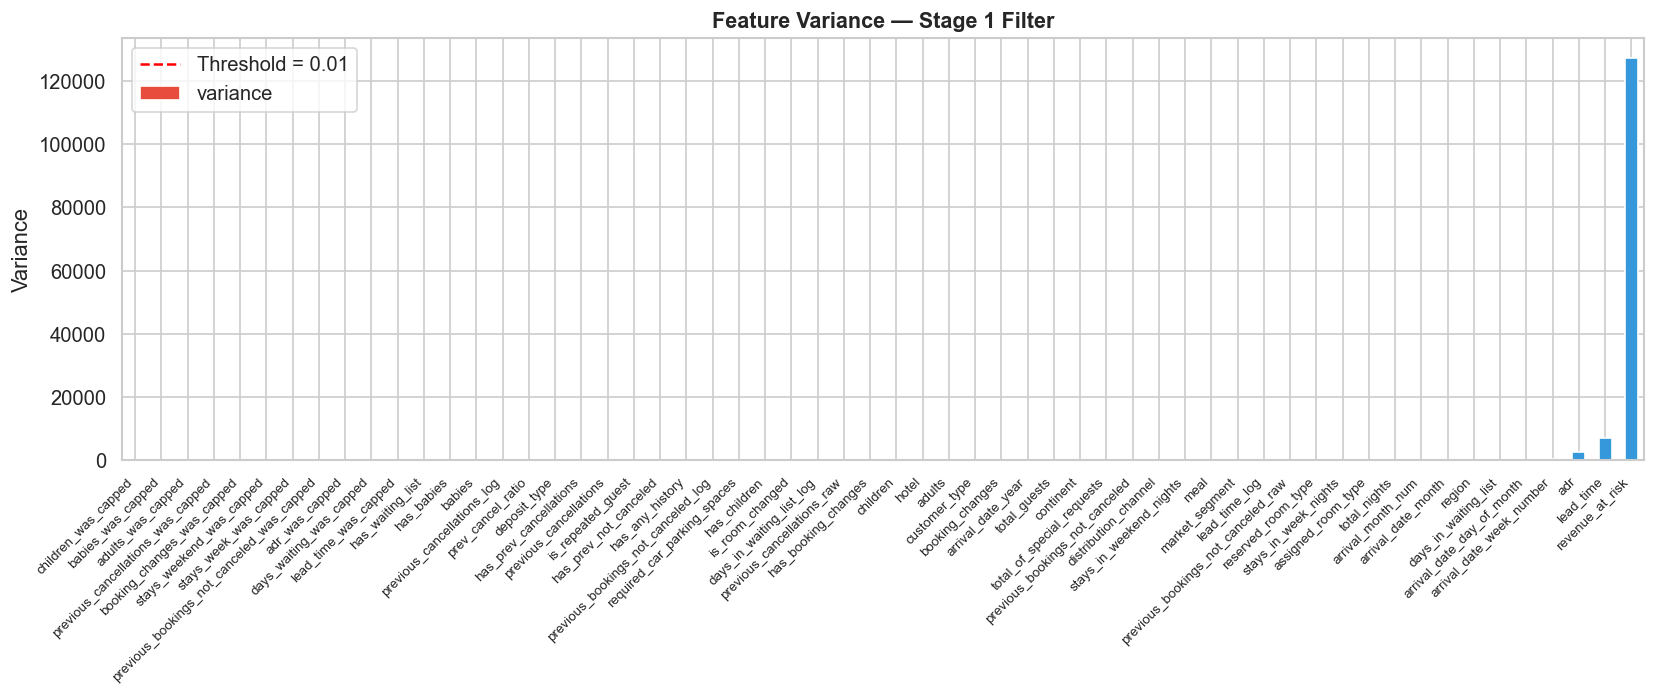

In [10]:
# visualise variance per feature
variances = pd.Series(X_train.var(), name='variance').sort_values()

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#E74C3C' if v < 0.01 else '#3498DB' for v in variances.values]
variances.plot(kind='bar', ax=ax, color=colors)
ax.axhline(y=0.01, color='red', linestyle='--', linewidth=1.5,
           label='Threshold = 0.01')
ax.set_title('Feature Variance — Stage 1 Filter', fontsize=13, fontweight='bold')
ax.set_ylabel('Variance')
ax.set_xlabel('')
ax.set_xticklabels(variances.index, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('feature_selection_visuals/31_variance_threshold.png', bbox_inches='tight')
plt.show()

### 4. Stage 2 - filter method: mutual information

Mutual Information measures how much knowing a feature reduces uncertainty about the target. It captures non-linear relationships unlike correlation, making it ideal for tree-based models.

In [11]:
# mutual information
print('Computing mutual information scores...')
MI_THRESHOLD = 0.005

mi_scores = mutual_info_classif(
    X_train[features_after_var],
    y_train,
    random_state=SEED,
    n_neighbors=5
)

mi_df = pd.Series(
    mi_scores,
    index=features_after_var,
    name='mutual_information'
).sort_values(ascending=False)

features_after_mi = mi_df[mi_df >= MI_THRESHOLD].index.tolist()
mi_dropped = mi_df[mi_df < MI_THRESHOLD].index.tolist()

print("Dropped low MI:", mi_dropped)
print("Remaining:", len(features_after_mi))

Computing mutual information scores...
Dropped low MI: ['previous_bookings_not_canceled_raw', 'has_prev_cancellations', 'assigned_room_type', 'arrival_date_week_number', 'stays_in_weekend_nights', 'children', 'arrival_month_num', 'arrival_date_month', 'has_children', 'hotel', 'days_in_waiting_list_log', 'reserved_room_type', 'days_in_waiting_list', 'meal', 'babies', 'arrival_date_day_of_month', 'has_any_history', 'has_babies']
Remaining: 28


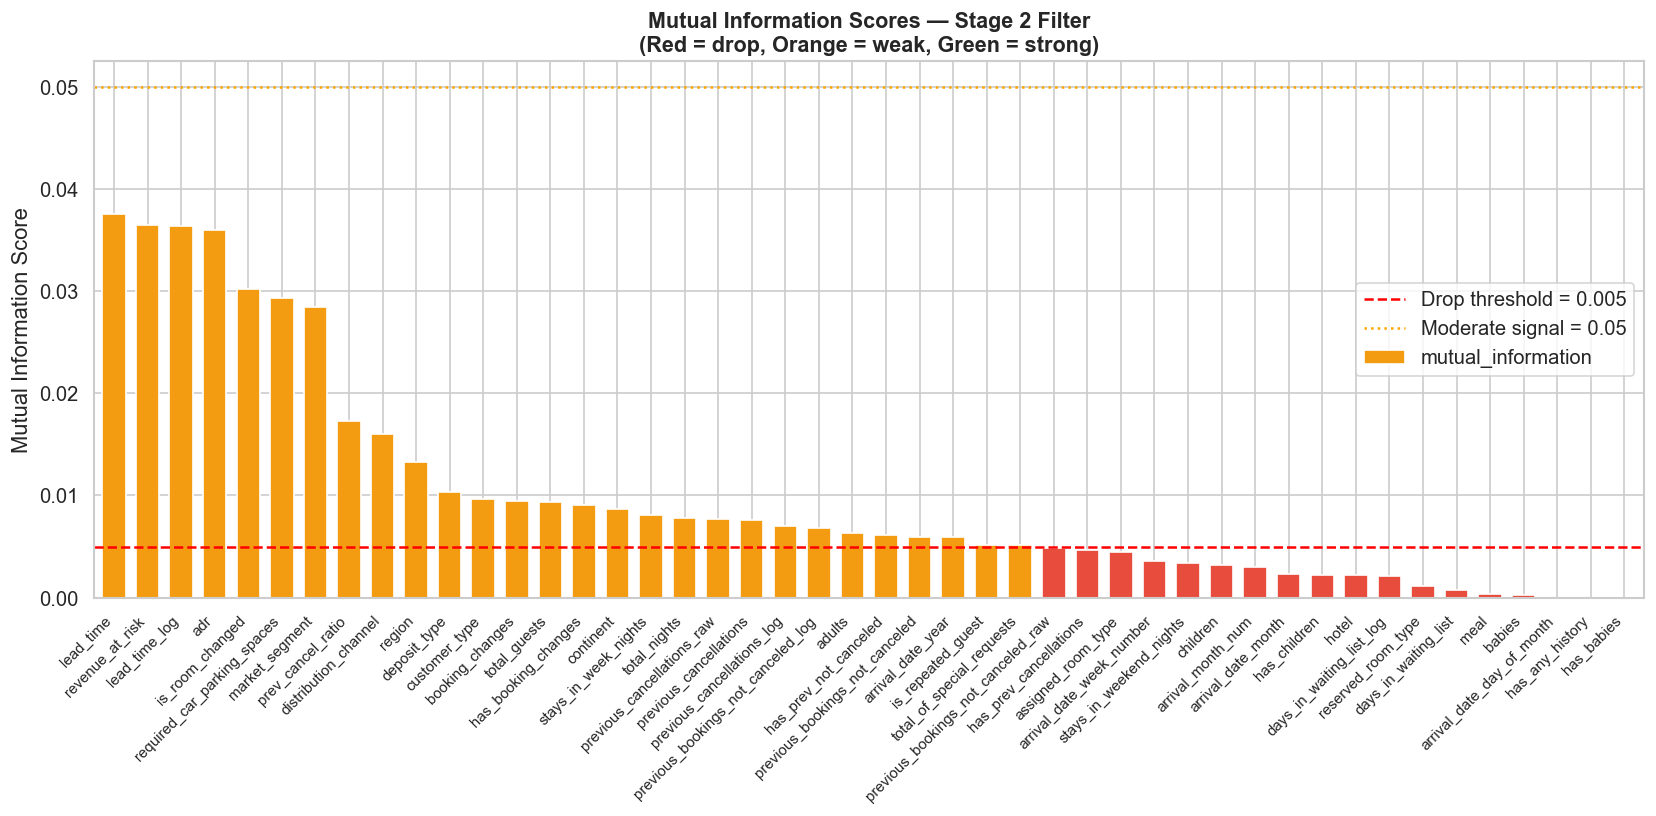

In [12]:
# visualize
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#E74C3C' if v < MI_THRESHOLD else
          '#F39C12' if v < 0.05 else
          '#2ECC71'
          for v in mi_df.values]
mi_df.plot(kind='bar', ax=ax, color=colors, width=0.7)
ax.axhline(y=MI_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Drop threshold = {MI_THRESHOLD}')
ax.axhline(y=0.05, color='orange', linestyle=':', linewidth=1.5,
           label='Moderate signal = 0.05')
ax.set_title('Mutual Information Scores — Stage 2 Filter\n'
             '(Red = drop, Orange = weak, Green = strong)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mutual Information Score')
ax.set_xlabel('')
ax.set_xticklabels(mi_df.index, rotation=45, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('feature_selection_visuals/32_mutual_information.png', bbox_inches='tight')
plt.show()

### 5. Stage 3 - Embedded Method: XGBoost Feature Importance

We train a quick XGBoost model and examine the importance it assigns to each feature. This is called an embedded method because feature selection happens as part of the model training process itself.

We use two importance types:
- **weight**: how many times a feature is used to split across all trees
- **gain**: the average improvement in accuracy when a feature is used to split (more meaningful)

In [13]:
# xgb model for feature importance
print('Training XGBoost for feature importance...')

xgb = XGBClassifier(
    n_estimators=250,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=SEED,
    eval_metric="auc",
    n_jobs=-1
)

xgb.fit(X_train[features_after_mi], y_train, verbose=False)

# Get both importance types
importance_weight = pd.Series(xgb.get_booster().get_score(importance_type='weight'), name='weight')
importance_gain = pd.Series(xgb.get_booster().get_score(importance_type='gain'),name='gain')

# Combine into one DataFrame
importance_df = pd.concat([importance_gain, importance_weight], axis=1).fillna(0)

# Normalize to 0-1 for comparison
importance_df['weight_norm'] = importance_df['weight'] / importance_df['weight'].max()
importance_df['gain_norm'] = importance_df['gain']   / importance_df['gain'].max()
importance_df['combined_norm'] = (importance_df['weight_norm'] + importance_df['gain_norm']) / 2
importance_df = importance_df.sort_values('gain', ascending=False)

print(f'\nTop 15 features by XGBoost gain importance:')
print(importance_df['gain'].head(15).round(2).to_string())

Training XGBoost for feature importance...

Top 15 features by XGBoost gain importance:
required_car_parking_spaces           359.99
is_room_changed                       253.74
lead_time_log                         135.41
region                                111.88
previous_cancellations                102.56
deposit_type                           97.52
market_segment                         97.09
total_of_special_requests              92.38
prev_cancel_ratio                      76.32
customer_type                          42.23
has_prev_not_canceled                  39.16
lead_time                              38.05
booking_changes                        35.80
previous_bookings_not_canceled_log     35.42
previous_cancellations_raw             34.74


In [14]:
XGB_IMPORTANCE_THRESHOLD = 0.005
all_zero_not_used = [f for f in features_after_mi if f not in importance_df.index]
low_gain = importance_df[importance_df["gain_norm"] < XGB_IMPORTANCE_THRESHOLD].index.tolist()
xgb_dropped = sorted(set(low_gain + all_zero_not_used))
features_after_xgb = [f for f in features_after_mi if f not in xgb_dropped]

print("Dropped low/zero XGB gain:", len(xgb_dropped))
print("Remaining:", len(features_after_xgb))


Dropped low/zero XGB gain: 1
Remaining: 27


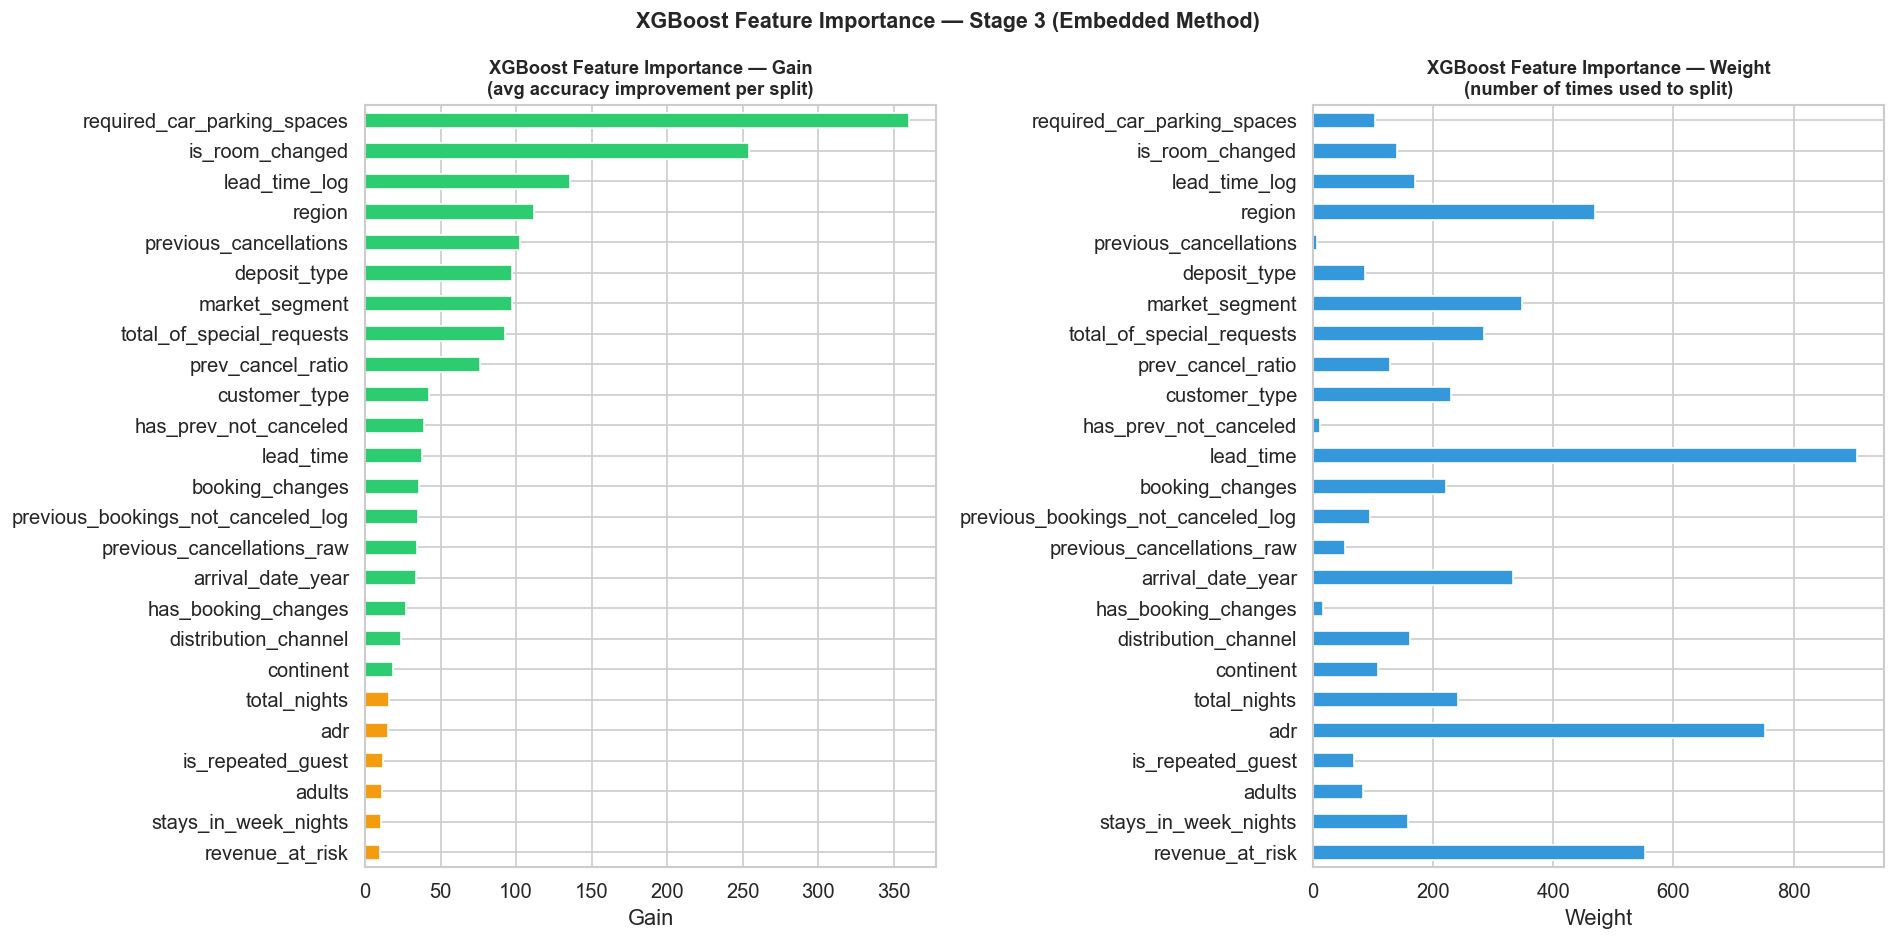

In [15]:
# visualize

top_n = 25  # show top 25 for readability
plot_df = importance_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gain importance
colors_gain = ['#2ECC71' if v > 0.05 else
               '#F39C12' if v > 0.01 else
               '#E74C3C'
               for v in plot_df['gain_norm'].values]
plot_df['gain'].plot(kind='barh', ax=axes[0], color=colors_gain)
axes[0].set_title('XGBoost Feature Importance — Gain\n(avg accuracy improvement per split)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Gain')
axes[0].invert_yaxis()

# Weight importance
plot_df['weight'].plot(kind='barh', ax=axes[1], color='#3498DB')
axes[1].set_title('XGBoost Feature Importance — Weight\n(number of times used to split)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Weight')
axes[1].invert_yaxis()

plt.suptitle('XGBoost Feature Importance — Stage 3 (Embedded Method)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection_visuals/33_xgboost_importance.png', bbox_inches='tight')
plt.show()

### 6. Stage 4 - Correlation Analysis

Two features that are highly correlated with each other carry redundant information. Keeping both doesn't improve the model but adds noise and slows training. We drop one from each highly correlated pair, keeping the one with higher XGBoost importance.

In [16]:
# correlation matrix
CORR_THRESHOLD = 0.85  # drop one from pairs with correlation above this

corr_matrix = X_train[features_after_xgb].corr().abs()

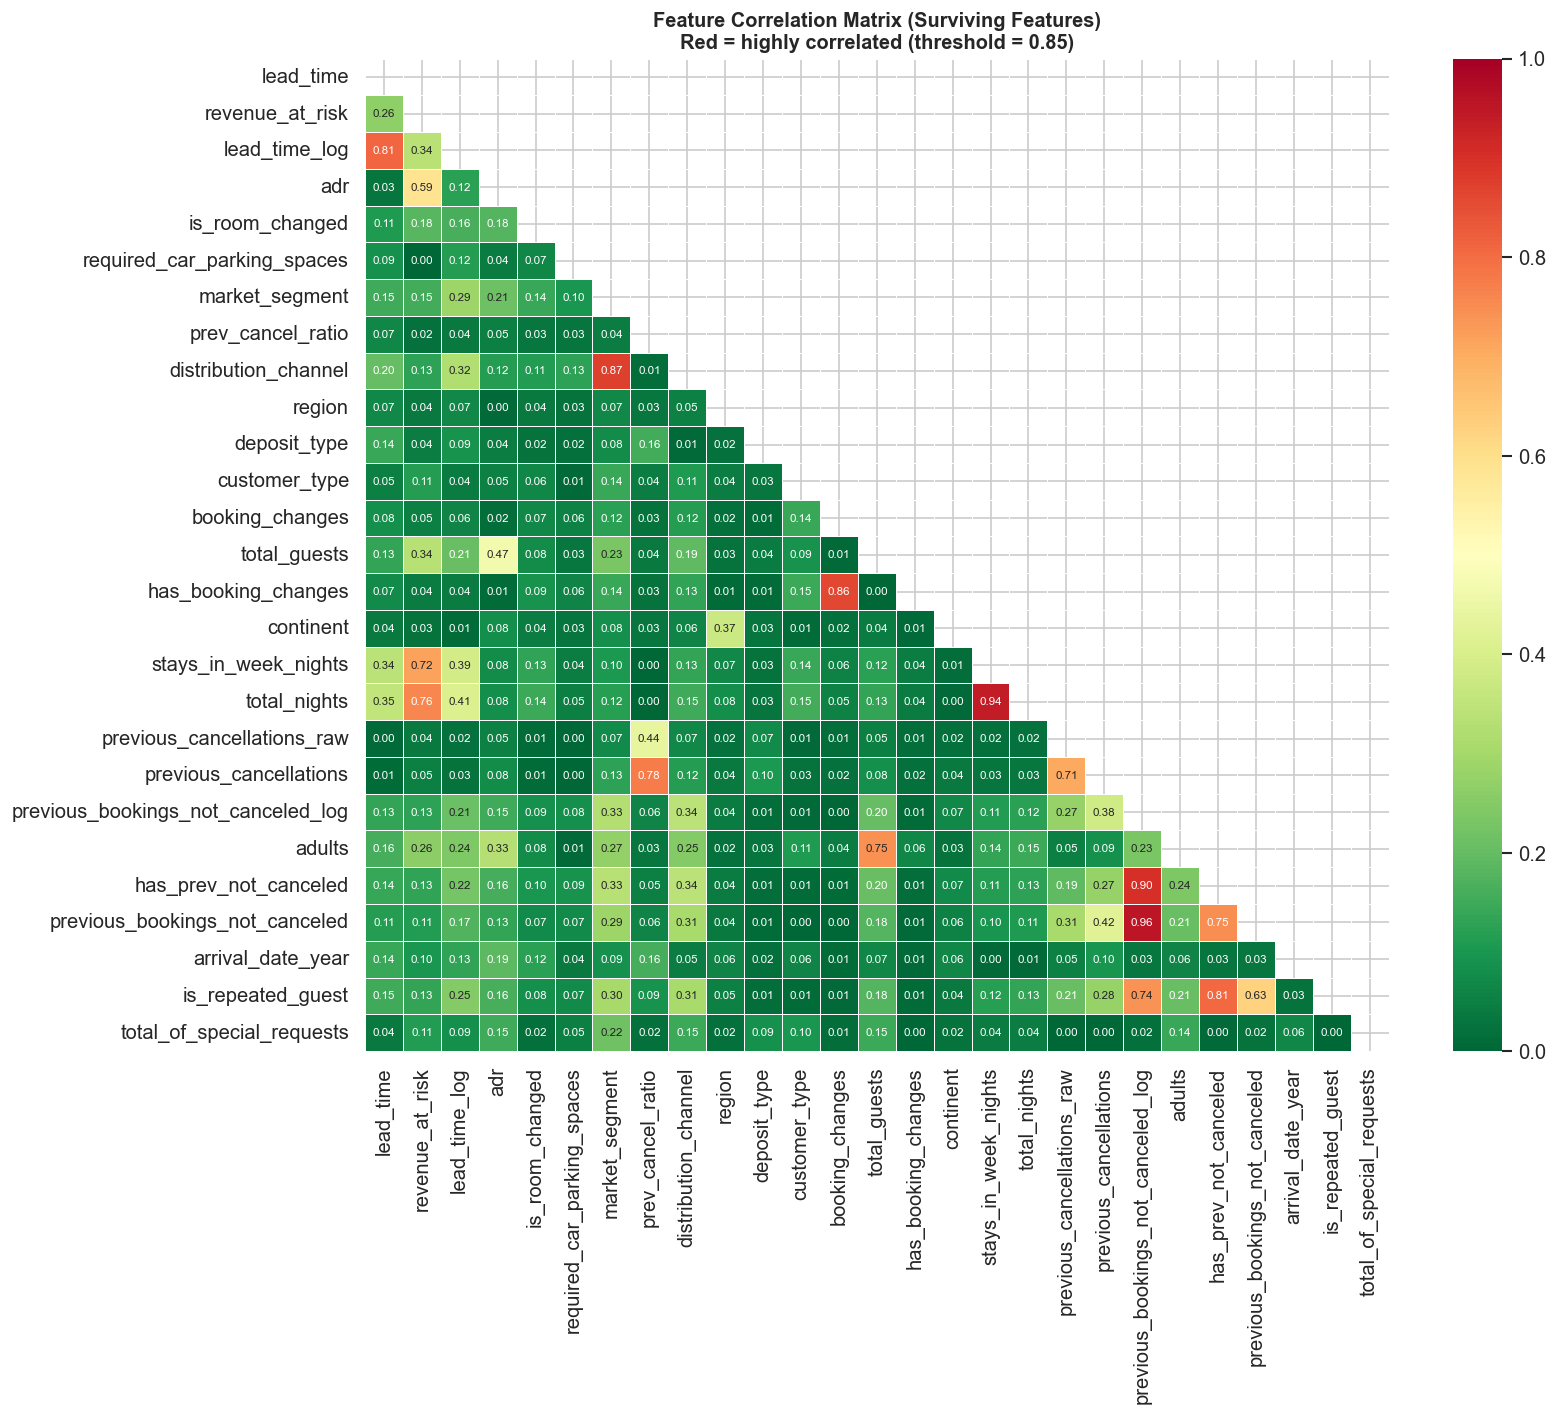

In [17]:
# plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0.5, ax=ax,
    linewidths=0.3, annot_kws={'size': 7},
    vmin=0, vmax=1
)
ax.set_title(f'Feature Correlation Matrix (Surviving Features)\n'
             f'Red = highly correlated (threshold = {CORR_THRESHOLD})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection_visuals/34_correlation_matrix.png', bbox_inches='tight')
plt.show()

In [18]:
# drop one from each highly correlated pair, keeping the one with higher XGBoost gain importance

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_dropped = set()
for col in upper.columns:
    high_corr_rows = upper.index[upper[col] > CORR_THRESHOLD].tolist()
    for row in high_corr_rows:
        gain_col = importance_df.loc[col, "gain"] if col in importance_df.index else 0
        gain_row = importance_df.loc[row, "gain"] if row in importance_df.index else 0
        to_drop = row if gain_col >= gain_row else col
        corr_dropped.add(to_drop)

corr_dropped = list(corr_dropped)
features_after_corr = [f for f in features_after_xgb if f not in corr_dropped]

print(f'Features dropped by correlation filter: {corr_dropped if corr_dropped else "None"}')
print(f'Features remaining after correlation filter: {len(features_after_corr)}')

Features dropped by correlation filter: ['previous_bookings_not_canceled_log', 'stays_in_week_nights', 'has_booking_changes', 'previous_bookings_not_canceled', 'distribution_channel']
Features remaining after correlation filter: 22


### 7. Performance check

In [19]:
# evaluation after each selection stage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_auc(feature_list, label):
    model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=SEED,
        eval_metric="auc",
        n_jobs=-1
    )
    scores = cross_val_score(
        model,
        X_train[feature_list],
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    return {
        "stage": label,
        "n_features": len(feature_list),
        "auc_mean": scores.mean(),
        "auc_std": scores.std()
    }

stage_results = []
stage_results.append(cv_auc(X_train.columns.tolist(), "Baseline: All Features"))
stage_results.append(cv_auc(features_after_var,  "Stage 1: After Variance"))
stage_results.append(cv_auc(features_after_mi,   "Stage 2: After MI"))
stage_results.append(cv_auc(features_after_xgb,  "Stage 3: After XGBoost"))
stage_results.append(cv_auc(features_after_corr, "Stage 4: After Correlation"))

results_df = pd.DataFrame(stage_results)
print("CV AUC by stage:")
display(results_df)

best_idx = results_df["auc_mean"].idxmax()
best_row = results_df.loc[best_idx]
print(f"Best stage: {best_row['stage']} | AUC={best_row['auc_mean']:.4f} ± {best_row['auc_std']:.4f}")


CV AUC by stage:


,stage,n_features,auc_mean,auc_std
0,Baseline: All Features,58,0.894744,0.001315
1,Stage 1: After Variance,46,0.895520,0.001231
2,Stage 2: After MI,28,0.889167,0.001351
3,Stage 3: After XGBoost,27,0.889384,0.001475
4,Stage 4: After Correlation,22,0.889118,0.001315


Best stage: Stage 1: After Variance | AUC=0.8955 ± 0.0012


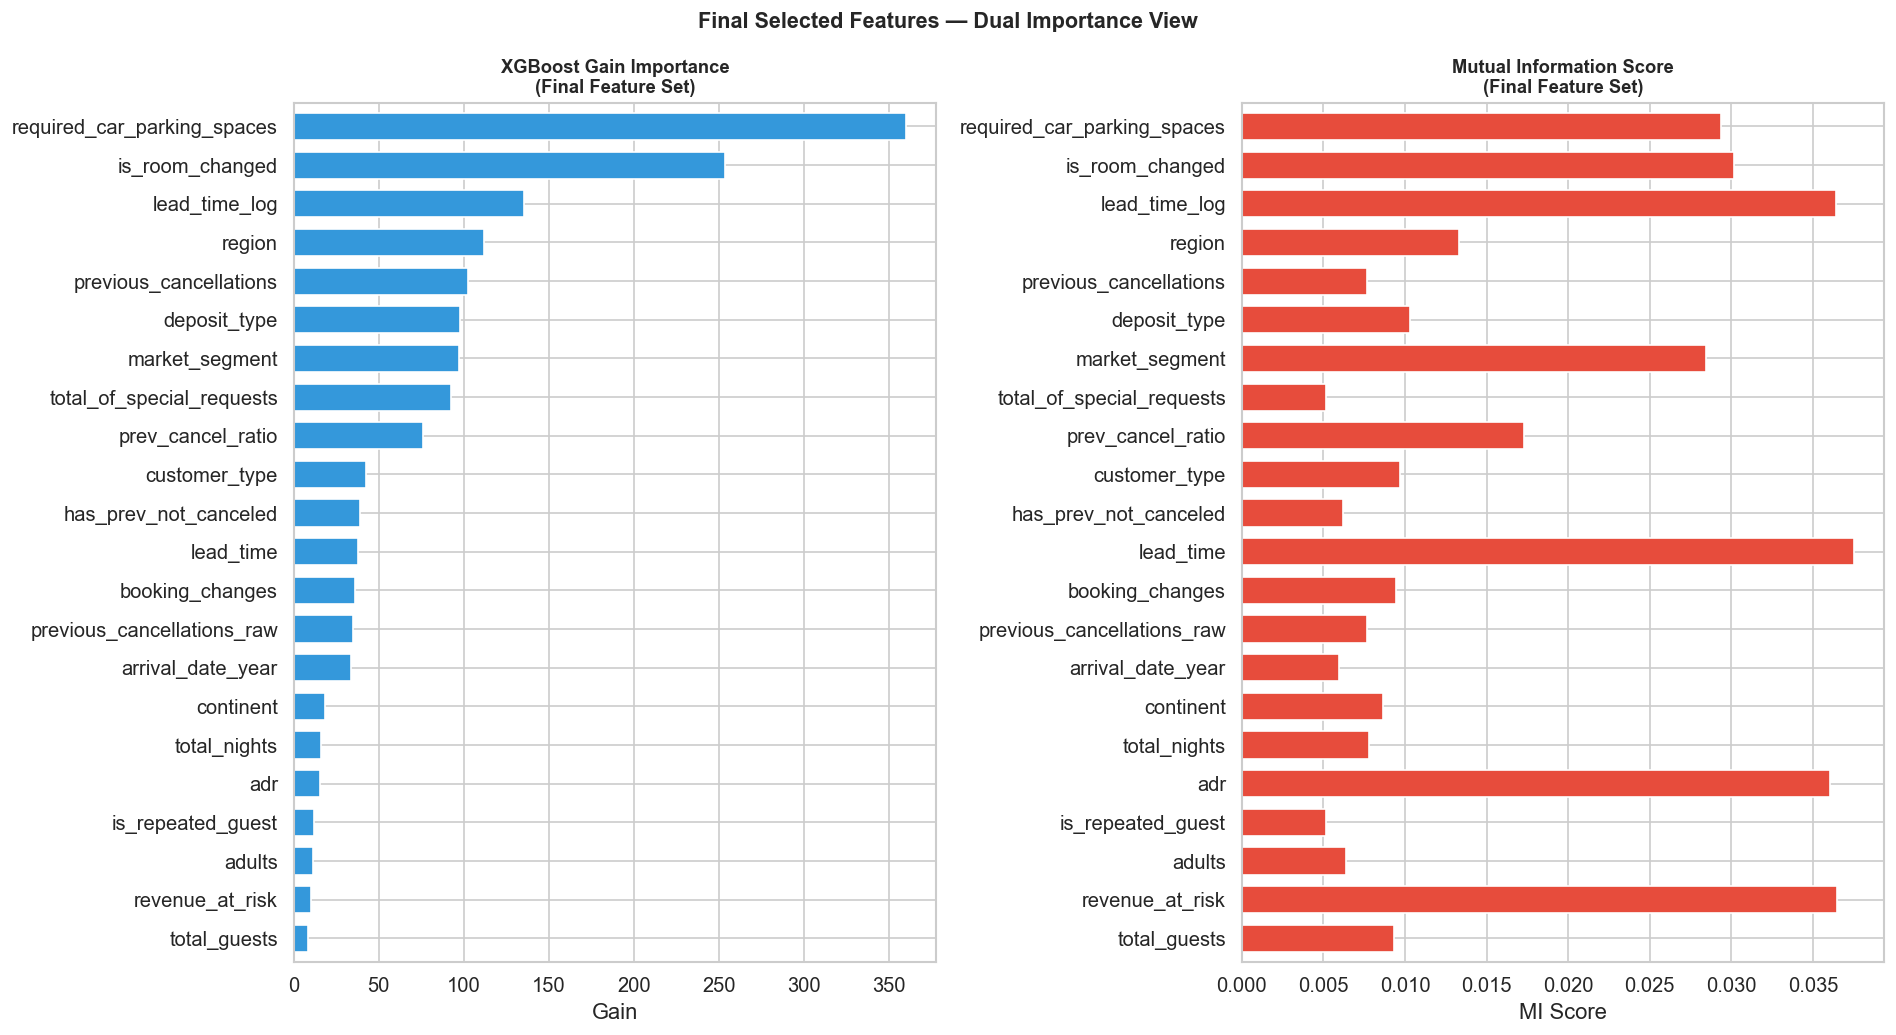

In [20]:
# combined importance chart for presentation

final_importance = importance_df.loc[
    [f for f in features_after_corr if f in importance_df.index]
].copy()

final_importance['mi_score'] = mi_df.reindex(final_importance.index).fillna(0)
final_importance = final_importance.sort_values('gain', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(final_importance) * 0.4)))

# XGBoost gain
final_importance['gain'].plot(
    kind='barh', ax=axes[0],
    color='#3498DB', width=0.7
)
axes[0].set_title('XGBoost Gain Importance\n(Final Feature Set)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Gain')

# Mutual Information
final_importance['mi_score'].plot(
    kind='barh', ax=axes[1],
    color='#E74C3C', width=0.7
)
axes[1].set_title('Mutual Information Score\n(Final Feature Set)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('MI Score')

plt.suptitle('Final Selected Features — Dual Importance View',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection_visuals/36_final_feature_importance.png', bbox_inches='tight')
plt.show()

In [21]:
# ── What each dropped feature was and why ─────────────────────────────────────
print('DROPPED FEATURES AUDIT')
print('-' * 55)

all_dropped = {
    **{f: 'Leakage / ID / Redundant date' for f in DROP_ALWAYS},
    **{f: 'Near-zero variance'            for f in low_variance_dropped},
    **{f: f'Low MI score ({mi_df.get(f,0):.4f})' for f in mi_dropped},
    **{f: 'Zero XGBoost gain'             for f in xgb_dropped},
    **{f: 'High correlation with better feature' for f in corr_dropped},
}

for feat, reason in all_dropped.items():
    print(f'  {feat:<45} → {reason}')

DROPPED FEATURES AUDIT
-------------------------------------------------------
  reservation_status                            → Leakage / ID / Redundant date
  reservation_status_date                       → Leakage / ID / Redundant date
  arrival_date                                  → Leakage / ID / Redundant date
  arrival_weekday                               → Leakage / ID / Redundant date
  lead_time_bucket                              → Leakage / ID / Redundant date
  country                                       → Leakage / ID / Redundant date
  country_code_iso3                             → Leakage / ID / Redundant date
  agent                                         → Leakage / ID / Redundant date
  company                                       → Leakage / ID / Redundant date
  adr_was_capped                                → Near-zero variance
  lead_time_was_capped                          → Near-zero variance
  stays_weekend_was_capped                      → Near-zero var

### 8. Exporting feature sets

In [22]:
import json
import pandas as pd

feature_sets = {
    "all_train_cols": X_train.columns.tolist(),
    "after_variance": features_after_var,
    "after_mi": features_after_mi,
    "after_xgb": features_after_xgb,
    "after_corr": features_after_corr
}

# save lists
with open("./data/feature_sets/feature_sets.json", "w", encoding="utf-8") as f:
    json.dump(feature_sets, f, indent=2)

print("Saved: ./data/feature_sets/feature_sets.json")


Saved: ./data/feature_sets/feature_sets.json


In [23]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(0), np.int64(0))